In [1]:
import numpy as np
import pandas as pd
from pandas.core.frame import DataFrame
from pathlib import Path
import os
import contextlib
from IPython.display import Image

from flatpack.src.config import Config
from flatpack.preproc import medium_risk_ext
from flatpack.preproc import make_containers
from flatpack.src import simulate_pathways
from flatpack.plot import plot_data
from flatpack.src import multi_simulate_pathways
from flatpack.plot import plot_multisim_data

In [2]:
def make_cpt(cpt_csv: str|Path, cal_port: bool=None) -> DataFrame:
    """
    Create virtual containers

    Parameters
    ----------
    cpt_csv : Union[str| Path]
        the path to the CSV file to use as the input table (for attribute proportions)

    Returns
    -------
    cpt: DataFrame
        the conidtional probability (of contamination 'p_yes') table
        with proportions ('prop') of the attribute values
    """

    # cal_vals = (False, True)
    schs_vals = ("no", "yes100", "yes50", "yes20", "yes5")
    rdest_vals = (False, True)
    tog_vals = ("none", "normal", "exceptions")
    
    cpt_df = pd.read_csv(cpt_csv)
    for _c in ('Arrivals', 'Inspections', 'LLC only', 'HLC only'):
        cpt_df.loc[:, _c] = cpt_df[_c].fillna(0)
    cpt_df = cpt_df.eval("Contaminated=(`LLC only` + `HLC only`)")

    if cpt_df['Type of goods'].isna().any():
        cpt_df.loc[:, 'Type of goods'] = cpt_df['Type of goods'].fillna("exceptions")
    cpt_df = cpt_df.rename(columns={'Type of goods': 'TypeOfGoods'})
    
    # cpt_df['RuralDest'] = cpt_df['RuralDest'].replace({"Rural": True, "Metro": False})
    # Avoid string to bool downcast. Instead workaround str to str, then cast to bool:
    cpt_df['RuralDest'] = cpt_df['RuralDest'].replace({"Rural": "Y", "Metro": ""}).astype("bool")

    for _c, _v in zip(('SCHS', 'RuralDest', 'TypeOfGoods'), (schs_vals, rdest_vals, tog_vals)):
        cpt_df[_c] = cpt_df[_c].astype("category")
        cpt_df[_c] = cpt_df[_c].cat.set_categories(_v)

    if cal_port is None:
        attribs = ['CAL', 'SCHS', 'RuralDest', 'TypeOfGoods']
    else:
        attribs = ['SCHS', 'RuralDest', 'TypeOfGoods']

    prp = cpt_df.groupby(attribs, observed=False) \
                .agg(prop=('Arrivals', "sum")) \
                .apply(lambda x: x / x.sum()) \
                .fillna(0).reset_index()
    prb = cpt_df.groupby(attribs, observed=False) \
                .agg(cont_sum=('Contaminated', "sum"), insp_sum=('Inspections', "sum")) \
                .apply(lambda x: x['cont_sum'] / x['insp_sum'], axis=1) \
                .fillna(0).rename('p_yes').reset_index()
    cpt = pd.merge(prp, prb, on=attribs)

    if cal_port is None:
        cpt.insert(0, 'CALSourceCountry', cpt['CAL'].map({"Yes": True, "No": False}))
        cpt = cpt.drop(columns='CAL')
    else:
        cpt.insert(0, 'CALSourceCountry', cal_port)
        extra = cpt.copy()
        extra['CALSourceCountry'] = not cal_port
        extra['prop'] = 0
        extra['p_yes'] = 0
        cpt = pd.concat([cpt, extra], ignore_index=True)

    return cpt.sort_values(by=['CALSourceCountry', 'RuralDest']).reset_index(drop=True)

## All four risk categories, based on Greg's latest (22/05/25) CP table

Greg has produced the table with "Monitor 2024" and "Current status" which clearly separate the containers into four categories:

In [3]:
lo_med_hi = pd.read_csv("GHOOD/cpt_for_ant.csv")
lo_med_hi

,Qtr,CAL,SCHS,Type of goods,RuralDest,Arrivals,Inspections,LLC only,HLC only,Actionable containers,Monitor 2024,Current status
0,1/01/2019 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
1,1/01/2020 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Monitor,Low-risk
2,1/07/2021 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
3,1/01/2023 0:00,No,no,NaN,Metro,2,NaN,0,0,NaN,Low,Low-risk
4,1/07/2023 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
...,...,...,...,...,...,...,...,...,...,...,...,...
418,1/10/2023 0:00,Yes,yes50,normal,Metro,4,4.0,0,0,NaN,Monitor,High-risk
419,1/04/2024 0:00,Yes,yes50,normal,Metro,17,17.0,1,0,NaN,Monitor,Medium-risk
420,1/07/2024 0:00,Yes,yes50,normal,Metro,3,3.0,0,0,NaN,Monitor,High-risk
421,1/10/2024 0:00,Yes,yes50,normal,Metro,7,7.0,0,1,NaN,Monitor,High-risk


Annual volume as fractions (to enter into the input YAML file):

In [4]:
lo_med_hi.groupby(pd.to_datetime(lo_med_hi['Qtr']).dt.year)['Arrivals'].sum() / lo_med_hi['Arrivals'].sum()

Qtr
2019    0.152155
2020    0.155498
2021    0.163021
2022    0.162962
2023    0.155823
2024    0.170847
2025    0.039692
Name: Arrivals, dtype: float64

The "Monitor" status containers still need an extra pre-processing step, so we extract those:

In [5]:
monitor = lo_med_hi.query('CAL.eq("No")').query('`Monitor 2024`.eq("Monitor")')
monitor.to_csv("GHOOD/monitor_only.csv", index=False)
monitor

,Qtr,CAL,SCHS,Type of goods,RuralDest,Arrivals,Inspections,LLC only,HLC only,Actionable containers,Monitor 2024,Current status
1,1/01/2020 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Monitor,Low-risk
5,1/07/2023 0:00,No,no,NaN,Metro,3,NaN,0,0,NaN,Monitor,Low-risk
9,1/01/2019 0:00,No,no,none,Metro,6185,NaN,0,0,NaN,Monitor,Low-risk
11,1/04/2019 0:00,No,no,none,Metro,8462,NaN,0,0,NaN,Monitor,Low-risk
13,1/07/2019 0:00,No,no,none,Metro,7440,NaN,0,0,NaN,Monitor,Low-risk
...,...,...,...,...,...,...,...,...,...,...,...,...
149,1/01/2024 0:00,No,no,normal,Rural,2837,2837.0,149,107,4.0,Monitor,Low-risk
151,1/04/2024 0:00,No,no,normal,Rural,2890,2890.0,155,73,16.0,Monitor,Low-risk
153,1/07/2024 0:00,No,no,normal,Rural,2382,2382.0,130,143,4.0,Monitor,Low-risk
155,1/10/2024 0:00,No,no,normal,Rural,2941,2941.0,90,169,2.0,Monitor,Low-risk


And here is the rest (low, medium, and high rosk), which can be preprocessed in a conventional way:

In [6]:
low = lo_med_hi.query('CAL.eq("No")').query('`Monitor 2024`.eq("Low")')
low.to_csv("GHOOD/low_only.csv", index=False)
low

,Qtr,CAL,SCHS,Type of goods,RuralDest,Arrivals,Inspections,LLC only,HLC only,Actionable containers,Monitor 2024,Current status
0,1/01/2019 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
2,1/07/2021 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
3,1/01/2023 0:00,No,no,NaN,Metro,2,NaN,0,0,NaN,Low,Low-risk
4,1/07/2023 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
6,1/10/2023 0:00,No,no,NaN,Metro,1,NaN,0,0,NaN,Low,Low-risk
...,...,...,...,...,...,...,...,...,...,...,...,...
148,1/01/2024 0:00,No,no,normal,Rural,10548,10548.0,225,180,9.0,Low,Low-risk
150,1/04/2024 0:00,No,no,normal,Rural,9501,9501.0,222,181,9.0,Low,Low-risk
152,1/07/2024 0:00,No,no,normal,Rural,10287,10287.0,242,227,12.0,Low,Low-risk
154,1/10/2024 0:00,No,no,normal,Rural,11272,11272.0,217,238,13.0,Low,Low-risk


In [7]:
med = lo_med_hi.query('CAL.eq("Yes")').query('`Current status`.eq("Medium-risk")')
med.to_csv("GHOOD/med_only.csv", index=False)
med

,Qtr,CAL,SCHS,Type of goods,RuralDest,Arrivals,Inspections,LLC only,HLC only,Actionable containers,Monitor 2024,Current status
159,1/01/2019 0:00,Yes,no,none,Metro,2501,1854.0,48,81,1.0,Monitor,Medium-risk
161,1/04/2019 0:00,Yes,no,none,Metro,2249,1307.0,64,9,NaN,Monitor,Medium-risk
163,1/07/2019 0:00,Yes,no,none,Metro,2438,1684.0,47,348,NaN,Monitor,Medium-risk
165,1/10/2019 0:00,Yes,no,none,Metro,1498,786.0,47,17,NaN,Monitor,Medium-risk
167,1/01/2020 0:00,Yes,no,none,Metro,2070,1394.0,56,31,1.0,Monitor,Medium-risk
...,...,...,...,...,...,...,...,...,...,...,...,...
409,1/07/2019 0:00,Yes,yes50,none,Metro,293,293.0,9,4,NaN,Monitor,Medium-risk
414,1/10/2024 0:00,Yes,yes50,none,Metro,16,16.0,1,0,NaN,Monitor,Medium-risk
417,1/07/2019 0:00,Yes,yes50,normal,Metro,28,28.0,2,1,NaN,Monitor,Medium-risk
419,1/04/2024 0:00,Yes,yes50,normal,Metro,17,17.0,1,0,NaN,Monitor,Medium-risk


In [8]:
high = lo_med_hi.query('CAL.eq("Yes")').query('`Current status`.eq("High-risk")')
high.to_csv("GHOOD/high_only.csv", index=False)
high

,Qtr,CAL,SCHS,Type of goods,RuralDest,Arrivals,Inspections,LLC only,HLC only,Actionable containers,Monitor 2024,Current status
158,1/01/2019 0:00,Yes,no,none,Metro,4604,4117.0,130,610,13.0,Monitor,High-risk
160,1/04/2019 0:00,Yes,no,none,Metro,5179,4549.0,207,940,4.0,Monitor,High-risk
162,1/07/2019 0:00,Yes,no,none,Metro,4392,3820.0,231,648,2.0,Monitor,High-risk
164,1/10/2019 0:00,Yes,no,none,Metro,5031,4410.0,216,730,16.0,Monitor,High-risk
166,1/01/2020 0:00,Yes,no,none,Metro,4650,4212.0,255,601,7.0,Monitor,High-risk
...,...,...,...,...,...,...,...,...,...,...,...,...
415,1/01/2025 0:00,Yes,yes50,none,Metro,41,41.0,0,0,NaN,Monitor,High-risk
416,1/07/2019 0:00,Yes,yes50,normal,Metro,14,14.0,3,0,NaN,Monitor,High-risk
418,1/10/2023 0:00,Yes,yes50,normal,Metro,4,4.0,0,0,NaN,Monitor,High-risk
420,1/07/2024 0:00,Yes,yes50,normal,Metro,3,3.0,0,0,NaN,Monitor,High-risk


Low to High risk container volumes, and the total volume:

In [9]:
low['Arrivals'].sum(), monitor['Arrivals'].sum(), med['Arrivals'].sum(), high['Arrivals'].sum(), lo_med_hi['Arrivals'].sum()

(11537306, 3113468, 112662, 149327, 14912763)

Make sure they add up:

In [10]:
11537306 + 3113468 + 112662 + 149327 == 14912763

True

Low, Monitor, Medium and High risk proportions:

In [11]:
print(11537306/14912763,  3113468/14912763,  112662/14912763, 149327/14912763)

0.7736531452957444 0.2087787487804909 0.00755473683850538 0.010013369085259384


Generate the 60 row (2x5x3x2, for the four container attribute combinations) conditional probability (CP) tables,
with the "prop" and "p_yes" columns (for the relative proportion and absolute contamination probability, respectively), and save them as CSV files.

First for low-risk containers:

In [12]:
cpt_low = make_cpt("GHOOD/low_only.csv", cal_port=False)
cpt_low.insert(4, 'CALSourceCountryMedium', False)
cpt_low

C:\Users\AB0175\AppData\Local\Temp\ipykernel_15952\1453436937.py:50: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: x['cont_sum'] / x['insp_sum'], axis=1) \


,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,False,2.288151e-02,0.000000
1,False,no,False,normal,False,9.534735e-01,0.000000
2,False,no,False,exceptions,False,6.067274e-07,0.000000
3,False,yes100,False,none,False,0.000000e+00,0.000000
4,False,yes100,False,normal,False,0.000000e+00,0.000000
5,False,yes100,False,exceptions,False,0.000000e+00,0.000000
6,False,yes50,False,none,False,0.000000e+00,0.000000
7,False,yes50,False,normal,False,0.000000e+00,0.000000
8,False,yes50,False,exceptions,False,0.000000e+00,0.000000
9,False,yes20,False,none,False,0.000000e+00,0.000000


There are only 4 rows with non-zero "prop", because these are non-CAL, with no SCHS applicable.
Furthermore, the only aplicable inspections (outside an odd CCV inspection) are on the FULL (i.e., "normal" type of goods) containers in rural areas (i.e., RuralDest True).
Hence, only the single row exhibits a non-zero "p_yes" value, observed in the rural tailgate (RTG) inspections:

In [13]:
cpt_low.query('prop.gt(0)')

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,False,2.288151e-02,0.000000
1,False,no,False,normal,False,9.534735e-01,0.000000
2,False,no,False,exceptions,False,6.067274e-07,0.000000
16,False,no,True,normal,False,2.364434e-02,0.057377


The CP table for the "Monitor" category of non-CAL containers:

In [14]:
cpt_monitor = make_cpt("GHOOD/monitor_only.csv", cal_port=False)
cpt_monitor.insert(4, 'CALSourceCountryMedium', True)
cpt_monitor

C:\Users\AB0175\AppData\Local\Temp\ipykernel_15952\1453436937.py:50: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: x['cont_sum'] / x['insp_sum'], axis=1) \


,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,True,0.050063,0.000000
1,False,no,False,normal,True,0.930396,0.000000
2,False,no,False,exceptions,True,0.000001,0.000000
3,False,yes100,False,none,True,0.000000,0.000000
4,False,yes100,False,normal,True,0.000000,0.000000
5,False,yes100,False,exceptions,True,0.000000,0.000000
6,False,yes50,False,none,True,0.000000,0.000000
7,False,yes50,False,normal,True,0.000000,0.000000
8,False,yes50,False,exceptions,True,0.000000,0.000000
9,False,yes20,False,none,True,0.000000,0.000000


Similarly, there are only 4 rows with non-zero "prop", because these are non-CAL, with no SCHS applicable.
Again, the only aplicable inspections (outside an odd CCV inspection) are on the FULL (i.e., "normal" type of goods) containers in rural areas (i.e., RuralDest True).
Hence, only the single row exhibits a non-zero "p_yes" value, observed in the rural tailgate (RTG) inspections:

In [15]:
cpt_monitor.query('prop.gt(0)')

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,True,0.050063,0.000000
1,False,no,False,normal,True,0.930396,0.000000
2,False,no,False,exceptions,True,0.000001,0.000000
16,False,no,True,normal,True,0.019539,0.085066


The CP table for the CAL container in the Medium risk category:

In [16]:
cpt_med = make_cpt("GHOOD/med_only.csv", cal_port=True)
cpt_med.insert(4, 'CALSourceCountryMedium', True)
cpt_med

C:\Users\AB0175\AppData\Local\Temp\ipykernel_15952\1453436937.py:50: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: x['cont_sum'] / x['insp_sum'], axis=1) \


,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,True,0.000000,0.000000
1,False,no,False,normal,True,0.000000,0.000000
2,False,no,False,exceptions,True,0.000000,0.000000
3,False,yes100,False,none,True,0.000000,0.000000
4,False,yes100,False,normal,True,0.000000,0.000000
5,False,yes100,False,exceptions,True,0.000000,0.000000
6,False,yes50,False,none,True,0.000000,0.000000
7,False,yes50,False,normal,True,0.000000,0.000000
8,False,yes50,False,exceptions,True,0.000000,0.000000
9,False,yes20,False,none,True,0.000000,0.000000


There are about dozen rows with non-zero "prop" and "p_yes" values, where both CALSourceCountry and CALSourceCountryMedium are True:

In [17]:
cpt_med.query('p_yes.gt(0)')

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
30,True,no,False,none,True,0.633079,0.164966
31,True,no,False,normal,True,0.327342,0.158834
33,True,yes100,False,none,True,0.006142,0.102601
34,True,yes100,False,normal,True,0.000541,0.147541
36,True,yes50,False,none,True,0.002743,0.045307
37,True,yes50,False,normal,True,0.000515,0.103448
39,True,yes20,False,none,True,0.003275,0.024390
40,True,yes20,False,normal,True,0.000320,0.083333
42,True,yes5,False,none,True,0.018507,0.026379
43,True,yes5,False,normal,True,0.007536,0.021201


The CP table for the high risk CAL containers:

In [18]:
cpt_high = make_cpt("GHOOD/high_only.csv", cal_port=True)
cpt_high.insert(4, 'CALSourceCountryMedium', False)
cpt_high

C:\Users\AB0175\AppData\Local\Temp\ipykernel_15952\1453436937.py:50: RuntimeWarning: invalid value encountered in scalar divide
  .apply(lambda x: x['cont_sum'] / x['insp_sum'], axis=1) \


,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
0,False,no,False,none,False,0.000000,0.000000
1,False,no,False,normal,False,0.000000,0.000000
2,False,no,False,exceptions,False,0.000000,0.000000
3,False,yes100,False,none,False,0.000000,0.000000
4,False,yes100,False,normal,False,0.000000,0.000000
5,False,yes100,False,exceptions,False,0.000000,0.000000
6,False,yes50,False,none,False,0.000000,0.000000
7,False,yes50,False,normal,False,0.000000,0.000000
8,False,yes50,False,exceptions,False,0.000000,0.000000
9,False,yes20,False,none,False,0.000000,0.000000


Non-zero "prop"/"p_yes" rows:

In [19]:
cpt_high.query('p_yes.gt(0)')

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_yes
30,True,no,False,none,False,0.768763,0.190086
31,True,no,False,normal,False,0.182847,0.179094
33,True,yes100,False,none,False,0.024704,0.063974
34,True,yes100,False,normal,False,0.000603,0.032967
36,True,yes50,False,none,False,0.007159,0.072965
37,True,yes50,False,normal,False,0.000188,0.142857
39,True,yes20,False,none,False,0.005886,0.060296
40,True,yes20,False,normal,False,0.000509,0.026316
42,True,yes5,False,none,False,0.007011,0.032474
43,True,yes5,False,normal,False,0.002330,0.048851


Adjust the relative "prop" values to account for the relative proportion of each of the 4 category in the total container population.
Then make sure the adjusted proportions add up to 1 (i.e., 100%):

In [20]:
cpt_low['prop'] = 0.7736531452957444 * cpt_low['prop']
cpt_monitor['prop'] = 0.2087787487804909 * cpt_monitor['prop']
cpt_med['prop'] = 0.00755473683850538 * cpt_med['prop']
cpt_high['prop'] = 0.010013369085259384 * cpt_high['prop']

cpt_low['prop'].sum() + cpt_monitor['prop'].sum() + cpt_med['prop'].sum() + cpt_high['prop'].sum()  

Now the 4 tables can be mergeed in the common CPT, with the new "p_no" column (simply 1-"p_yes"): 

In [22]:
cpt_all = pd.concat([cpt_low.query('~CALSourceCountry'), cpt_monitor.query('~CALSourceCountry'), cpt_med.query('CALSourceCountry'), cpt_high.query('CALSourceCountry')], ignore_index=True)
cpt_all.insert(6, 'p_no', 1-cpt_all['p_yes'])
cpt_all

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_no,p_yes
0,False,no,False,none,False,1.770235e-02,1.0,0.0
1,False,no,False,normal,False,7.376578e-01,1.0,0.0
2,False,no,False,exceptions,False,4.693966e-07,1.0,0.0
3,False,yes100,False,none,False,0.000000e+00,1.0,0.0
4,False,yes100,False,normal,False,0.000000e+00,1.0,0.0
...,...,...,...,...,...,...,...,...
115,True,yes20,True,normal,False,0.000000e+00,1.0,0.0
116,True,yes20,True,exceptions,False,0.000000e+00,1.0,0.0
117,True,yes5,True,none,False,0.000000e+00,1.0,0.0
118,True,yes5,True,normal,False,0.000000e+00,1.0,0.0


In [24]:
cpt_all.query('p_yes.gt(0)')

,CALSourceCountry,SCHS,RuralDest,TypeOfGoods,CALSourceCountryMedium,prop,p_no,p_yes
16,False,no,True,normal,False,0.018293,0.942623,0.057377
46,False,no,True,normal,True,0.004079,0.914934,0.085066
60,True,no,False,none,True,0.004783,0.835034,0.164966
61,True,no,False,normal,True,0.002473,0.841166,0.158834
63,True,yes100,False,none,True,0.000046,0.897399,0.102601
64,True,yes100,False,normal,True,0.000004,0.852459,0.147541
66,True,yes50,False,none,True,0.000021,0.954693,0.045307
67,True,yes50,False,normal,True,0.000004,0.896552,0.103448
69,True,yes20,False,none,True,0.000025,0.975610,0.024390
70,True,yes20,False,normal,True,0.000002,0.916667,0.083333


Only the top two rows are the non-CAL contributions, from the low-risk and Monitor categories, respectively. Both "p_yes" values are from the RTG inspections.

We must "extrapolate" (i.e., impute) the rural-tailgate detected contamination to the urban-bound (i.e., with RuralDest False) non-CAL containers, too:

In [25]:
cpt_all.loc[~cpt_all['CALSourceCountry'] & cpt_all['SCHS'].eq("no") & cpt_all['RuralDest'].eq(False) & cpt_all['TypeOfGoods'].eq("normal") & ~cpt_all['CALSourceCountryMedium'], 'p_yes'] = 0.057377
cpt_all.loc[~cpt_all['CALSourceCountry'] & cpt_all['SCHS'].eq("no") & cpt_all['RuralDest'].eq(False) & cpt_all['TypeOfGoods'].eq("normal") & ~cpt_all['CALSourceCountryMedium'], 'p_no'] = 0.942623

cpt_all.loc[~cpt_all['CALSourceCountry'] & cpt_all['SCHS'].eq("no") & cpt_all['RuralDest'].eq(False) & cpt_all['TypeOfGoods'].eq("normal") & cpt_all['CALSourceCountryMedium'], 'p_yes'] = 0.085066
cpt_all.loc[~cpt_all['CALSourceCountry'] & cpt_all['SCHS'].eq("no") & cpt_all['RuralDest'].eq(False) & cpt_all['TypeOfGoods'].eq("normal") & cpt_all['CALSourceCountryMedium'], 'p_no'] = 0.914934

Make sure that "prop" adds up to 1, and "p_yes" + "p_no" to 120 (i.e., 1 for each row):

In [26]:
cpt_all['prop'].sum(), cpt_all['p_yes'].sum(), cpt_all['p_no'].sum()

Make a new subdirs "CPT" (inside "GHOOD"), followed by "ALL_FOUR"  (inside "CPT") and save the CP table as a CSV file namd "cpt_all_with_med":

In [28]:
(Path.cwd() / "GHOOD" / "CPT" / "ALL_FOUR").mkdir(parents=True, exist_ok=True)

cpt_all.sort_values(by=['CALSourceCountry', 'RuralDest']).reset_index(drop=True).to_csv("GHOOD/CPT/ALL_FOUR/cpt_all_with_med.csv", index=False)

The approach rate for the CAL Medium risk container is 0.00755473683850538 (or 7.55%, their proportion, see above).

Their relative fraction (as one of the two CAL categiries):

In [29]:
med['Arrivals'].sum() / (med['Arrivals'].sum() + high['Arrivals'].sum())

We need to enter the CAL Medium approach rate and fraction in the input_all.yaml file (inside "GHOOD" folder):

In [31]:
!cat GHOOD/input_all.yaml

inputs:
  data:
    data_dir: ./CPTS
    ext_dir: ALL_FOUR
    top_cpt: cpt_all
  cal_medium_approach_rate: 0.00755
  cal_medium_fraction: 0.43
  virtconts:
    vcon_dir: ./virtual_containers
    tot_containers: 100000
    num_label: "1e5"
    tot_importers:
      - name: "2019"
        volume: 0.152155
      - name: "2020"
        volume: 0.155498
      - name: "2021"
        volume: 0.163021
      - name: "2022"
        volume: 0.162962
      - name: "2023"
        volume: 0.155823
      - name: "2024"
        volume: 0.170847
      - name: "2025"
      - volume: 0.039692

work:
  w_dir: ./results
  vis_dir: ./output_plots
  single_dir: raw
  multi_dir: multi
  sim_total: 20
  old: all_old
  new: all_new

sensi_rates:
  schs_daff_sensitivity: 0.93
  cal_aa_inspect_fraction: 0.4
  aa_frac_or_num: 0.02
  ccv_frac_or_num: 0.005
  cal_tailgate_daff_sensitivity: 0.8
  cal_tailgate_aa_sensitivity: 0.6
  daff_ccv_sensitivity: 0.3
  rural_tailgate_aa_sensitivity: 0.5
  rural_tailgate_daff_se


Now change directory to "GHOOD" and execute the workflow (the 3 _"with ..."_ lines are not needed, remove those , and the indents from the rest, to see potential errors):

In [ ]:
os.chdir("GHOOD")
with contextlib.suppress(FileNotFoundError):
    with contextlib.suppress(OSError):
        with contextlib.suppress(PermissionError):
            conf = Config("input_all.yaml")
            # medium_risk_ext.main(conf)            # Adds CALSourceCountryMedium to CPT. SKIP it, already preprocessed above.
            make_containers.main(conf)              # Generates the virtual containers.
            simulate_pathways.main(conf)            # Carries out a single simulation.
            plot_data.run_individual_outputs(conf)  # Plots the results of the simulation.
            multi_simulate_pathways.main(conf)      # Performs the required number of simulations.
            plot_multisim_data.main(conf)           # Plots the results of the simulations.

Old (i.e., current), new with CBIS and new with SCHS treatment produce the following contaminations in 100k arrivals, respectively:

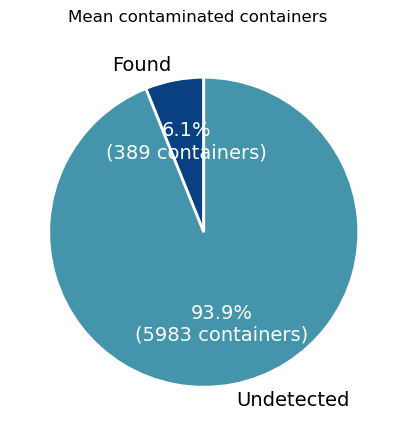

In [41]:
Image(filename = "output_plots/multi/all_old/summary_all_old_contamination_breakdown.png", width=250, height=250)

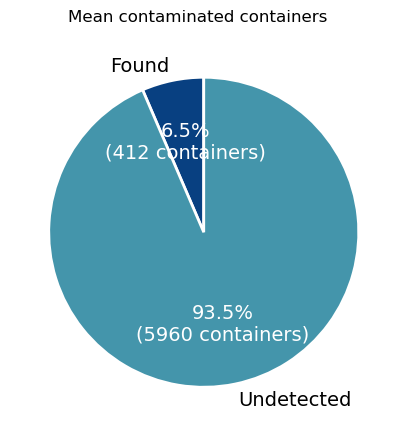

In [42]:
Image(filename = "output_plots/multi/all_new/summary_all_new_contamination_breakdown.png", width=250, height=250)

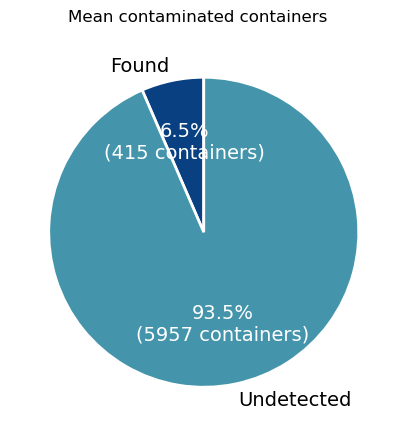

In [43]:
Image(filename = "output_plots/multi/all_new_schs/summary_all_new_schs_contamination_breakdown.png", width=250, height=250)

Old (i.e., current), new with CBIS and new with SCHS treatment produce the following node inspections in 100k arrivals, respectively:

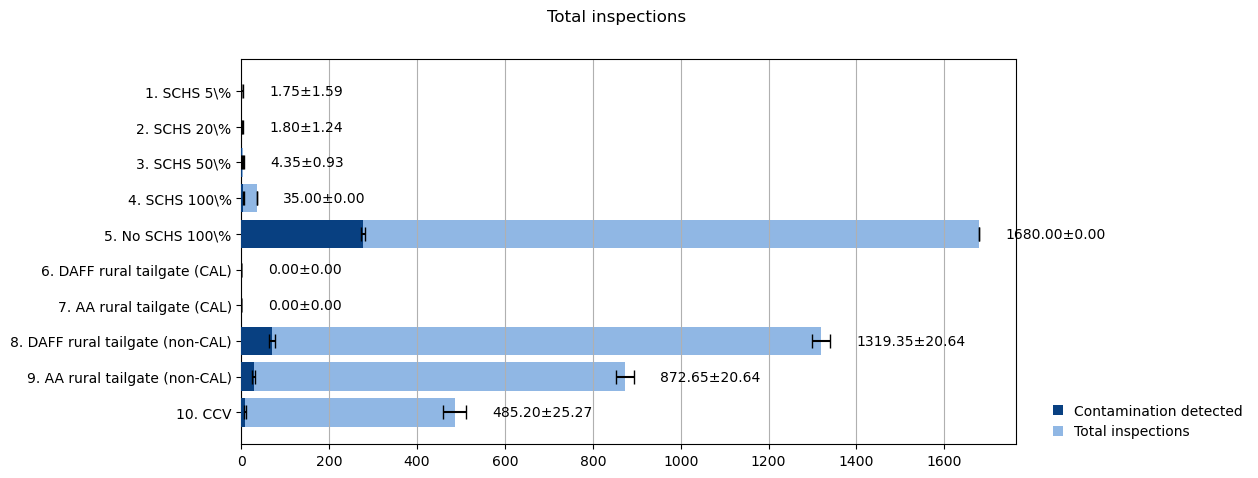

In [44]:
Image(filename = "output_plots/multi/all_old/all_old_summary_bar.png", width=1000, height=1000)

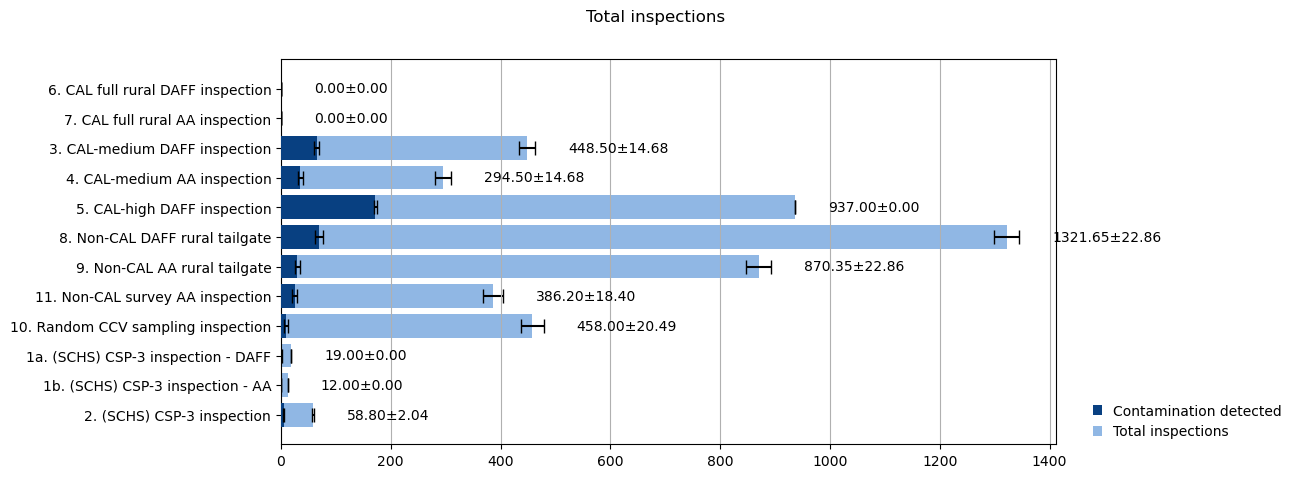

In [45]:
Image(filename = "output_plots/multi/all_new/all_new_summary_bar.png", width=1000, height=1000)

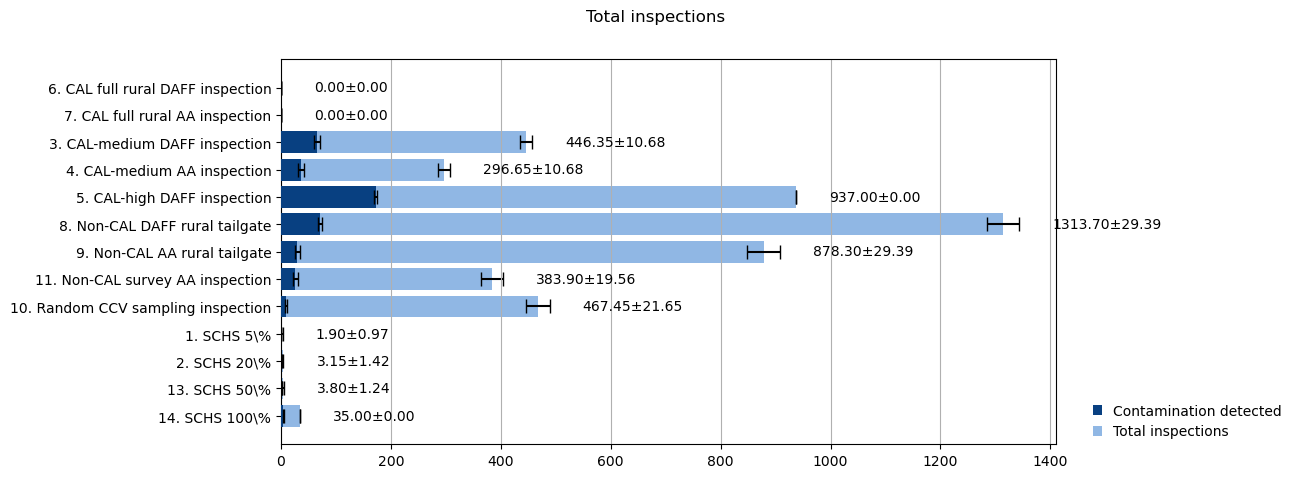

In [46]:
Image(filename = "output_plots/multi/all_new_schs/all_new_schs_summary_bar.png", width=1000, height=1000)